In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:16pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="6" color="red">ch10. N차원 배열다루기</font>
 - N차원 배열 객체: 동일 자료형의 집합
 - 2차원 배열은 행렬개념으로 이해
 - [numpy](https://numpy.org/)
 - [numpy API doc](https://numpy.org/doc/stable/reference/index.html)
 # 1장. 넘파이 패키지

In [2]:
import numpy as np
np.__version__ #tensorflow==2.10과 맞는 numpy 버전


'1.23.5'

In [5]:
#np.arange(from,stop,by) : from 부터 stop앞까지 by씩 증가하는 1차원 정수 배열
a = np.arange(15)
print(a.shape) #차원  15열짜리 1차원배열
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [4]:
list(range(15))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

## 1.1 배열속성

In [21]:
from numpy import arange
a = arange(15,dtype=np.int32).reshape(3,5)
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [7]:
type(a) #a변수의 타입

numpy.ndarray

In [12]:
a.dtype #a배열의 요소(item)들의 type   #int32   int  32비트 차지

dtype('int32')

In [22]:
a.dtype.name

'int32'

In [23]:
a.itemsize #한 요소(item)의 bytesize   8bit = 1byte로 

4

In [25]:
a.ndim #축수(차원수)

2

In [26]:
a.size #배열 요소의 갯수

15

In [15]:
a.shape  #배열구조(1차원 15열)

(3, 5)

In [29]:
print('shape 조정전 a:\n',a)
a.shape = (5,3)
print('shape 조정후 a:\n',a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


In [30]:
a.reshape(3,5)

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [31]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

## 1.2 배열 타입 변경

In [34]:
#배열 요소의 타입변경(x)
a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [36]:
a.size # 요소갯수

12

In [39]:
a.dtype #32bit씩 읽겠다 (4byte씩)

dtype('int32')

In [40]:
a.itemsize

4

In [42]:
a.dtype=np.int64   ## 이렇게 type 변경하면 요소값이 변하게 된다!!! 
a.dtype

dtype('int64')

In [43]:
a.itemsize

8

In [44]:
a

array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [45]:
a.size

6

In [47]:
#배열 요소의 타입변경(o)
a=arange(15).reshape(5,3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [49]:
a.astype(np.int64)  # 값이 리턴되는건 a값을 변경한건 아니다
                        # 출력o -> ark 바뀌지 않음. 출력x ->a바뀜

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [51]:
a.dtype

dtype('int32')

In [52]:
a=a.astype(np.int64) # a에 할당하면 a값이 변경이된다!

In [53]:
a.dtype

dtype('int64')

In [54]:
a.itemsize

8

In [55]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [56]:
a. ravel() #flaten된 배열 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

In [57]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

## 1.3 배열 저장
- pkl(객체, 배열, 머신러닝 모델 저장) vs npy(넘파이 전용포맷, io개선)

In [58]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [65]:
# import time
# start = time.time()
# import pickle
# with open('data/ch10_pkl','wb') as f : 
#     pickle.dump(a,f)
# end =time.time()
# print('실행시간은 :',end-start)

실행시간은 : 0.007020473480224609


In [73]:
%%time
import pickle
with open('data/ch10.pkl','wb') as f : 
    pickle.dump(a,f)

CPU times: total: 0 ns
Wall time: 961 µs


In [72]:
%%time
with open('data/ch10_pkl','rb') as f :
    loaded_a= pickle.load(f)

CPU times: total: 0 ns
Wall time: 0 ns


In [71]:
# a==(파일저장)==> 피클파일(269B) ==>(load)==>loaded_a
loaded_a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [74]:
%%time
np.save('data/ch11.npy',a) #넘파이전용포맷. 빠르고 효율적 안전

CPU times: total: 0 ns
Wall time: 1.44 ms


In [75]:
%%time
loaded_a2=np.load('data/ch11.npy')

CPU times: total: 0 ns
Wall time: 995 µs


In [76]:
# a ==(저장) ==>npy(248B) ==(load)==> loaded_a2
loaded_a2

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

# 2장. 넘파이배열
- array()함수를 이용한 다른 파이썬 데이터구조(list, tup)를 배열변환
- 특정값을 갖는 배열 생성함수 : arange, ones, zeros, full, empty.......
- 랜덤값을 갖는 배열 생성함수 : ....
- [넘파이함수들](https://numpy.org/doc/stable/reference/index.html)
## 2.1 array()함수로 넘파이 배열 만들기
- array(obj, dtype=np.type, copy=T/F)
- array(obj. dtype='type', copy=T/F) type 예 : int16, int32, float16, float32, float64,...

In [78]:
a=np.array([2, 14, 6])   #기본으로 dtype=np.int32  실수의 기본타입은 float64
a

array([ 2, 14,  6])

In [81]:
a[0],a[1],a[2]

(2, 14, 6)

In [82]:
for item in a : 
    print(item, end='\t')

2	14	6	

In [89]:
b=np.array([[1.5,2.3],[4,5]])  #동일자료형의 집합으로 배열 생성 : 정수>실수>문자
                                # 실수 배열의 기본타입 : float64
b.dtype

dtype('float64')

In [91]:
l=[[1.5,2.3],[4,5]]    ## 2차원리스트 인덱싱
l[0][1]

2.3

In [92]:
b[0,1] #2차원 [axis0=행,axis1=열] cf. 1차원[axis0=열]



2.3

In [95]:
a= np.array([[1.5, 2.3],
            [4,5]],dtype=np.float32).reshape(1,4)   #   dtype=np.float32  또는 dtype='float32' 
a
#a=a.astype(np.int64)

array([[1.5, 2.3, 4. , 5. ]], dtype=float32)

In [94]:
a.dtype

dtype('float32')

In [97]:
#a의 배열 구조 변경
a.shape=(2,2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [ ]:
# a의 dtype(요소의 타입)변경

In [99]:
a=a.astype(np.float16)

In [100]:
a.dtype

dtype('float16')

In [107]:
l = [[1.5, 2.3],[4,5]]
for row in l:
    for item in row:
        print(item, end=" ")

1.5 2.3 4 5 

In [118]:
for i, row in enumerate(a):
    for j, item in enumerate(row):
#         print(f"{i}행{j}열 : {l[i][j]}", end='\t') #float16은 소숫점이하가 불안정
          print(f"{i}행{j}열 : {a[i,j]}", end='\t')
    print()

0행0열 : 1.5	0행1열 : 2.30078125	
1행0열 : 4.0	1행1열 : 5.0	


In [122]:
# 인덱싱
print(b[0,0]) #인덱싱
# print(b[0,2]) # 없는 인덱싱은 에러

SyntaxError: invalid syntax (2712534814.py, line 3)

In [125]:
#슬라이싱 from : stop : by : from부터 stop전까지 by씩 전진. 인덱싱은 음수도 가능
b[0:,1:10] #0~끝행, 1열부터 10열까지 슬라이싱(행과 열 모두 슬라이싱 2차원 배열)

array([[2.3],
       [5. ]])

In [126]:
b[0,1:3]    #0행,1열부터3열전까지(열만 슬라이싱 1차원 배열)

array([2.3])

In [127]:
b[0:1,1:3]

array([[2.3]])

In [145]:
b=np.array([[1,2,3],[6,7,8]])


#모든행의 마지막 열만 추출
b[:,-1:]

array([[3],
       [8]])

In [ ]:
#모든행의 마지막 열만 제외한부분추출

In [146]:
b[:,:-1]

array([[1, 2],
       [6, 7]])

In [156]:
#스칼라 변수
a=10 
b=a
print("a={},b={}, a주소={},b주소={}".format(a,b,id(a),id(b)))
b=-1
print("a={},b={}, a주소={},b주소={}변경후".format(a,b,id(a),id(b)))

a=10,b=10, a주소=1241064538640,b주소=1241064538640
a=10,b=-1, a주소=1241064538640,b주소=1241064538288변경후


In [172]:
#numpy 배열
c=np.array([[1,2],[3,4]],dtype=np.uint8) # 원본 
#d = np.array(c, copy=False) #d=c 동일 할당
d = np.array(c, copy=True) #d=c.copy와 동일 #깊은 복사
#d = c.copy() #할당
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:', id(c),id(d))
d[0,0]=9

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소: 1241205403024 1241205403504


In [170]:
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:', id(c),id(d))

c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소: 1241205406000 1241205397744


In [ ]:
#copy=False해도 깊은 복사가 되는 경우 : dtype이 바뀌면 자동 깊은 복사
c=np.array([[1,2],[3,4]],dtype=np.uint8) # 원본 
d = np.array(c, copy=False, dtype=np.uint16)
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:', id(c),id(d))
d[0,0]=9

## 2.2 기본값이 있는 배열 만들기
- np.zeros( tup, [dtype] ) : 요소들이 다 0.0
- np.ones(tup, [dtype] ) : 요소들이 다 1.0
- np.full(tup, 기본값) : 요소들이 다 두번째 매개변수인 기본값
- np.empty(tup) : 초기 내용은 임의의 값인 배열(메모리 상태에 따라 달라짐)

※ 위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64, dtype속성을 따로 지정할 수 있음


In [232]:
np.zeros((3,5),dtype=np.int32)  #3행5열짜리 2차원 float64 배열(요소들은 다 0)
np.zeros((5,))#5열짜리 1차원 float64 배열(요소들은 다 0)
np.zeros(5)

array([0., 0., 0., 0., 0.])

In [235]:
x = np.zeros((2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[False False False False False]
 [False False False False False]]
bool
1


In [238]:
np.ones((3,5),dtype=np.int32)  #3행5열짜리 2차원 float64 배열(요소들은 다 1)
np.ones((5,))#5열짜리 1차원 float64 배열(요소들은 다 1)
np.ones(5)

array([1., 1., 1., 1., 1.])

In [239]:
x = np.ones((2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


In [241]:
x= np.full((2,5),255.0)
print(x)
print(x.dtype)

[[255. 255. 255. 255. 255.]
 [255. 255. 255. 255. 255.]]
float64


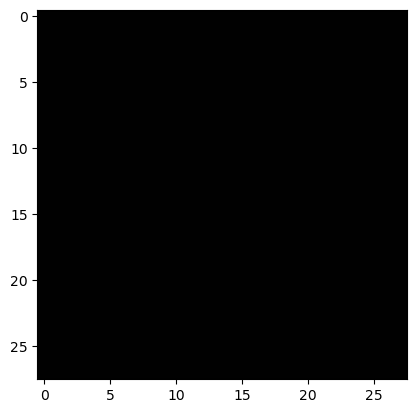

In [274]:
import matplotlib.pyplot as plt
img = np.full((28,28),200,dtype=np.uint8)
img = np.full((28,28),100,dtype=np.uint8)
img = np.zeros((28,28),dtype=np.uint8)
img = np.ones((28,28),dtype=np.uint8)
plt.imshow(img, cmap='gray',vmin=0,vmax=255)
#plt.axis('off')
plt.show()


In [273]:
np.empty((3,2))

array([[0.37472222, 0.33722222],
       [0.37472222, 4.03322222],
       [4.07072222, 0.33722222]])

## 2.3 랜덤값을 갖는 배열 만들기
※n차원 배열 만들기
- np.random.random( tup ) : 0부터 1 미만의 균등 분포를 갖는 tup shape 사이즈 랜덤값
- np.random.uinform(low=0, high=1.0, size=tup) : low부터 high 미만까지 균등분포를 갖는 랜덤값
- np.random.normal(loc=0.0, scale=1.0, size=tup) : 평균 loc, 표준편차scale을 갖는 정규분포 랜덤값
---
※1차원 배열 만들기
- np.random.rand(n) : 균등분포의 1차원 0~1미만 난수 배열 발생(난수가 n개)
- np.random.randn(n) :  표준정규분포(평균0, 표준편차가 1인 정규분포)의 1차원 난수 배열 발생(난수 n 개)
---
※난수1개 만들기
- np.random.randint(n) : 0부터 n미만의 정수 난수 1개발생 == random.randint(0,n-1)
- np.random.randint(from,to) : from 부터 to 미만의 정수 난수 1개 발생 == random.ranint(from, to-1)

In [303]:
np.random.random((2,3))

array([[0.7165162 , 0.00888643, 0.41729944],
       [0.64725212, 0.29791897, 0.23736275]])

In [304]:
np.random.rand(100000)

array([0.78251493, 0.55948619, 0.45843703, ..., 0.68263518, 0.09888834,
       0.20618118])

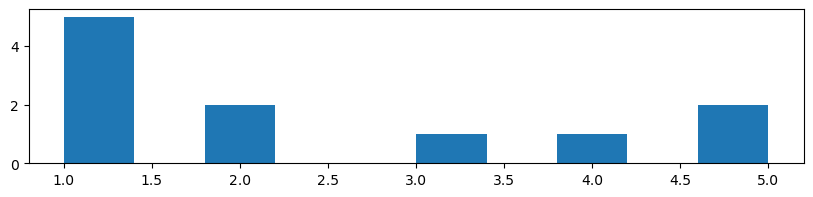

In [310]:
plt.figure(figsize=(10,2)) # 그래프 사이즈 조절
x = [1, 2, 3, 1, 1, 1, 2 ,1, 4, 5, 5] 
plt.hist(x, bins=10)
plt.show()

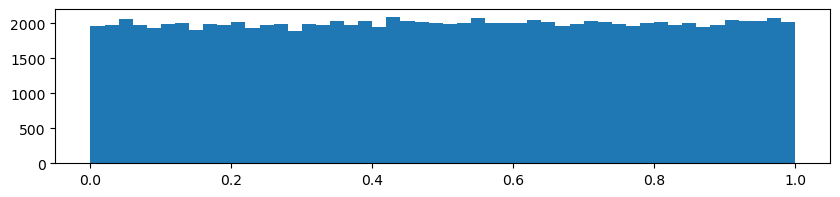

In [326]:
plt.figure(figsize=(10,2)) # 그래프 사이즈 조절
#x = np.random.random(100000)
#x = np.random.uniform(1,10, 100000)
x = np.random.rand(100000)
plt.hist(x, bins=50)
plt.show()

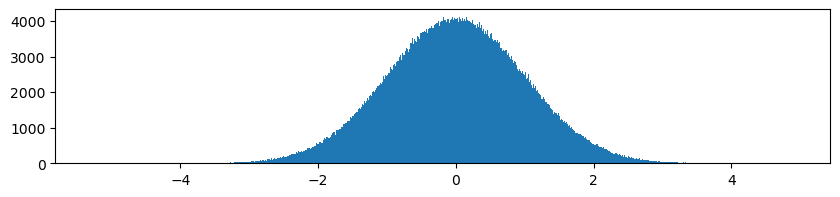

In [337]:
plt.figure(figsize=(10,2)) # 그래프 사이즈 조절
#x = np.random.random(100000)     
#x = np.random.uniform(1,10, 100000)
x = np.random.normal(50,10,1000000)     # 정규분포
x = np.random.normal(0,1,1000000)     # 정규분포
x = np.random.randn(1000000)#표준정규분포  
plt.hist(x, bins=1000)
plt.show()

In [16]:
#2차원 균등분포 난수(0~1미만 실수 난수) 배열
import numpy as np
from numpy import arange
#np.random.seed(3) seed값을 맞추면 발생되는 난수가 동일. seed값을 초기화하려면 커널 재시작
np.random.random((2,5) )  #2행 5열짜리 2차원 난수 배열


array([[0.5507979 , 0.70814782, 0.29090474, 0.51082761, 0.89294695],
       [0.89629309, 0.12558531, 0.20724288, 0.0514672 , 0.44080984]])

In [20]:
#2차원 균등분포 난수(-1~1미만 실수 난수) 배열
np.random.uniform(-1,1,(2,5)) #2행 5열 

array([[-0.18696017, -0.0621195 , -0.46152884, -0.41641445, -0.0846272 ],
       [ 0.72106783,  0.17250581, -0.43302428, -0.44404499, -0.09075585]])

In [21]:
#2차원 정규분포 난수(평균3에 표준편차1인 실수난수) 배열
np.random.normal(3,1,(1,5)) #1행 5열 2차원 배열

array([[2.40335036, 2.41140562, 2.1261177 , 3.02971382, 0.75174223]])

In [22]:
#1차원 균등분포 난수 배열
np.random.rand(3)
np.random.random(3)  #위아래가 같다!

array([0.70768662, 0.74674622, 0.69109292])

In [25]:
#1차원 표준정규분포(평균 0,표준편차1인 정규분포) 배열
np.random.randn(3)
np.random.normal(size=3)


array([-1.04882343,  1.30387239,  0.87614261])

## 2.4 연속된 값을 갖는 배열 만들기
- np.arange(from,to,by,dtype) : from부터 to(0거 정수일 경우to 미포함)앞까지 by씩 건너 뛴 값으 1차원 배열로 생성
- np.linspace(from,to,num) : from부터 to(to포함) 까지 num개 숫자들을 1차원 배열로 생성




In [28]:
np.arange(10,30,5,dtype=np.float32)

array([10., 15., 20., 25.], dtype=float32)

In [29]:
np.arange(0,2,0.3)

array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8])

In [33]:
np.linspace(0,3,20) #0부터 3까지 같은 간격으로 20개 수를 배열

array([0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895,
       0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263,
       1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632,
       2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ])

In [35]:
np.linspace(0,3,20).reshape(4,5)

array([[0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895],
       [0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263],
       [1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632],
       [2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ]])

In [45]:
x=np.array([0, 1, 2, 3, 4, 5, 6])
y=np.sin(x)

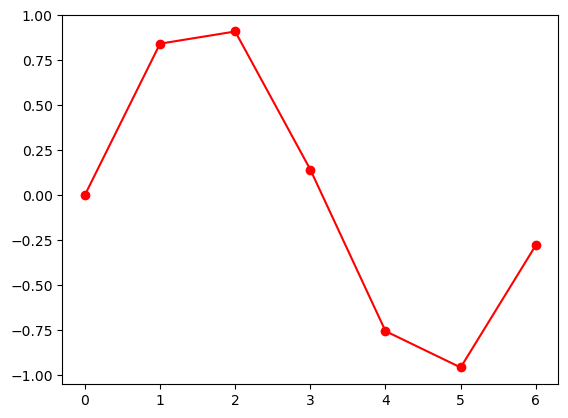

In [47]:
import matplotlib.pyplot as plt
plt.scatter(x,y,c="r") #빨간색 점그래프
plt.plot(x,y,c="r")
plt.show()


In [51]:
x=np.array([0, 1, 2, 3, 4, 5, 6])
#linspace : 특정 구간에 많은 수의 점을 생성할 때 유용
x=np.linspace(0,6,200)
y=np.sin(x)

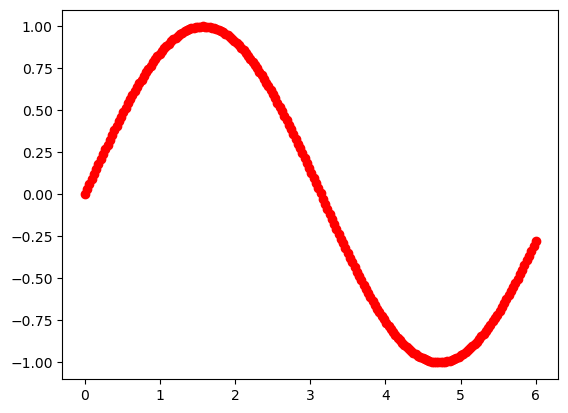

In [52]:
plt.scatter(x,y,c="r") #빨간색 점그래프
plt.plot(x,y,c="r")
plt.show()

## 2.5 배열의 차원변경
- reshape(행수,열수) : 차원 변경된 배열 return(-1가능)
- resize((행수,열수)) : 배열을 차원 변경(-1불가)
- ravel(), flatten() : 1차원이로 변경된 배열 return
- T : 전치행렬로 변환된 배열을 return
- transpose() : 전치행렬로 변환된 배열을 return
※ 실행결과가 출력되면 배열이 수정되지 않고. 실행결과가 없으면 배열이 수정됨

In [54]:
t=np.random.random((2,5))
t

array([[0.95210124, 0.68161178, 0.54101967, 0.7071806 , 0.26388667],
       [0.92672568, 0.83919306, 0.7263195 , 0.48023996, 0.84210319]])

In [58]:
#t*10 요소별 연산
#round() : 스칼라 값을 반올림
a=np.round(t*10)
a

array([[10.,  7.,  5.,  7.,  3.],
       [ 9.,  8.,  7.,  5.,  8.]])

In [60]:
a=a.astype(np.int16) #astype()을 이용한 요소별 타입변환
a

array([[10,  7,  5,  7,  3],
       [ 9,  8,  7,  5,  8]], dtype=int16)

In [61]:
a.reshape(5,2)  #a가 바뀐건 아니다

array([[10,  7],
       [ 5,  7],
       [ 3,  9],
       [ 8,  7],
       [ 5,  8]], dtype=int16)

In [62]:
a.reshape(5,-1)  #-1이 주어지면 해당 차원의 크기가 자동 계산
                   # ex) a의 item이 10이니 5행으로 하면 2열로 자동계산

array([[10,  7],
       [ 5,  7],
       [ 3,  9],
       [ 8,  7],
       [ 5,  8]], dtype=int16)

In [64]:
a.reshape(-1,5)

array([[10,  7,  5,  7,  3],
       [ 9,  8,  7,  5,  8]], dtype=int16)

In [65]:
a.reshape(-1)

array([10,  7,  5,  7,  3,  9,  8,  7,  5,  8], dtype=int16)

In [66]:
a.resize(2,-1) #resize는 -1를 사용할 수 없다

ValueError: negative dimensions not allowed

In [69]:
a.resize((2,5)) # a를 바꿈
a

array([[10,  7,  5,  7,  3],
       [ 9,  8,  7,  5,  8]], dtype=int16)

In [74]:
a.ravel()

array([10,  7,  5,  7,  3,  9,  8,  7,  5,  8], dtype=int16)

In [75]:
a.flatten()

array([10,  7,  5,  7,  3,  9,  8,  7,  5,  8], dtype=int16)

In [76]:
a.T #a의 전치행렬 행과열을 뒤바꾼 행렬 (0행1열->1행0열)

array([[10,  9],
       [ 7,  8],
       [ 5,  7],
       [ 7,  5],
       [ 3,  8]], dtype=int16)

## 2.6 배열 인쇄

In [4]:
import numpy as np
print(np.arange(10000).reshape(100,100)) #item 객수가 1000개 까지만 나온다

[[   0    1    2    3    4    5    6    7    8    9   10   11   12   13
    14   15   16   17   18   19   20   21   22   23   24   25   26   27
    28   29   30   31   32   33   34   35   36   37   38   39   40   41
    42   43   44   45   46   47   48   49   50   51   52   53   54   55
    56   57   58   59   60   61   62   63   64   65   66   67   68   69
    70   71   72   73   74   75   76   77   78   79   80   81   82   83
    84   85   86   87   88   89   90   91   92   93   94   95   96   97
    98   99]
 [ 100  101  102  103  104  105  106  107  108  109  110  111  112  113
   114  115  116  117  118  119  120  121  122  123  124  125  126  127
   128  129  130  131  132  133  134  135  136  137  138  139  140  141
   142  143  144  145  146  147  148  149  150  151  152  153  154  155
   156  157  158  159  160  161  162  163  164  165  166  167  168  169
   170  171  172  173  174  175  176  177  178  179  180  181  182  183
   184  185  186  187  188  189  190  191  192  193

In [79]:
np.get_printoptions()['threshold'] #출력되는 limit

1000

In [3]:
#배열이 너무 커서 인쇄할 수 없는 경우 자동으로 건너뛰고 모서리 부분만 출력
#numpy의 인쇄옵션 변경(인쇄할 사이즈를 조정 )
np.set_printoptions(threshold=10000)#배열 10000개까지 출력하도록 옵션 세팅
np.set_printoptions(threshold=np.inf) # 무한대
import sys
np.set_printoptions(threshold=sys.maxsize)


In [89]:
np.get_printoptions()['threshold']

9223372036854775807

## 2.7 기본 연산 동작
### 1) 배열의 요소별 연산

In [5]:
a=np.array([10, 20, 30, 40],dtype=np.int8)  #최대 255
b=np.arange(4)
print(a) #배열을 print()함수에 넣으면 array와,(콤마)가 안나옴
print(b)

[10 20 30 40]
[0 1 2 3]


In [6]:
print([1,2,3])

[1, 2, 3]


In [10]:
c = a+b #요소별 + 연산(dtype은 큰거로, 정수와 실수연산은 실수로)
print(c.dtype)

int32


In [12]:
a+2

array([12, 22, 32, 42], dtype=int8)

In [13]:
a*b #요소별 연산시 dtype이 큰쪽인 int32


array([  0,  20,  60, 120])

In [14]:
a**b

array([    1,    20,   900, 64000], dtype=int32)

In [16]:
a <40

array([ True,  True,  True, False])

In [23]:
print(a[[0, 1, 2, 3]]) #index를 list로 
print(a[[ True,  True,  True, False]]) #boolean index
print(a[[0,1]])) #boolean index

[10 20 30 40]
[10 20 30]
[10 20]


In [24]:
# a배열에서 40미만인 데이터만 추출하려면 boolean index 사용
a[a<40]

array([10, 20, 30], dtype=int8)

In [25]:
#a배열에서 40미만인 데이터의 index
np.where(a<40)

(array([0, 1, 2], dtype=int64),)

### 2)행렬의 곱(@,dot함수) cf.*(요소별 곱)
- 2차원 배열은 행렬로 취급
- pdf 18page

In [31]:
A=np.array([[1,1],[0,1]])
print(A)
B=np.array([[2,0],[3,4]])
print(B)

[[1 1]
 [0 1]]
[[2 0]
 [3 4]]


In [32]:
print('요소별 곱 A*B',A*B, sep='\n')
print('행렬 곱 A@B',A@B, sep='\n')
print('행렬곱 A.dot(B)',A.dot(B), sep='\n')

요소별 곱 A*B
[[2 0]
 [0 4]]
행렬 곱 A@B
[[5 4]
 [3 4]]
행렬곱 A.dot(B)
[[5 4]
 [3 4]]


In [34]:
A=np.array([[1,2],
            [3,4]])
B=np.array([[-1,-1],
            [1,1]])
C=A@B
C

array([[1, 1],
       [1, 1]])

In [35]:
A=np.array([[-1,-1],
            [1,1]])
B=np.array([[1,2],
            [3,4]])
C=A@B
C

array([[-4, -6],
       [ 4,  6]])

In [36]:
A=np.array([[1,2],
            [3,4]])
B=np.array([[6],
            [7]])
C=A@B
C

array([[20],
       [46]])

In [37]:
A=np.array([[1,2],
            [3,4]])
B=np.array([[6],
            [7]])
C=B@A
C

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 1)

In [39]:
A=np.array([[1,2,3],
            [3,4,1]])
B=np.array([[0,0],
            [1,1],
            [-1,2]])
C=A@B
C

array([[-1,  8],
       [ 3,  6]])

In [40]:
A=np.array([[1,2,3],
            [3,4,1]])
B=np.array([[0,0],
            [1,1],
            [-1,2]])
C=B@A
C

array([[ 0,  0,  0],
       [ 4,  6,  4],
       [ 5,  6, -1]])

In [41]:
A=np.array([[2,0],
            [3,4]])
B=np.array([[1,0],
            [0,1]])
C=A@B
C

array([[2, 0],
       [3, 4]])

In [42]:
A=np.array([[2,0],
            [3,4]])
B=np.array([[1,0],
            [0,1]])
C=B@A
C

array([[2, 0],
       [3, 4]])

In [43]:
# a@b != b@a 
# a@단위행렬 = 단위행렬@a ; 단위행렬에서는 행렬곱의 교환법칙이 성립
# 단위행렬은 정방행렬
A = np.array([[1,0],
              [0,1]]) #2행2열짜리 단위행렬
B = np.array([[2,0],
              [3,4]]) 
print('A@B=',A@B, sep='\n')
print('B@A=',B@A, sep='\n')

A@B=
[[2 0]
 [3 4]]
B@A=
[[2 0]
 [3 4]]


In [47]:
#2행2열 단위행렬
np.eye(10,dtype=np.int32)

array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

### 3) 복합 대입 연산자 사용(+=,-=,...)
- 스칼라데이터에서는  a +=b, a=a+b
- 배열에서는 a +=b는 a= a+b와 다소 다르게 작동

In [52]:
a= np.ones((2,3),dtype='int8') #int8 <- 범위 -128~127
b= np.random.random((2,3)) #float64
print(a,b,sep='\n')

[[1 1 1]
 [1 1 1]]
[[0.1974799  0.5431711  0.16224278]
 [0.39838501 0.93639634 0.77603874]]


In [53]:
a += 5 # a = a+5  공간이 넉넉하다면 똑같다
a

array([[6, 6, 6],
       [6, 6, 6]], dtype=int8)

In [54]:
a += 255 # 공간이 부족하aus a에 오류가 생긴다
a

array([[5, 5, 5],
       [5, 5, 5]], dtype=int8)

In [56]:
a = a+255  #a+255를 요소별로 계산하여 새로운 a배열을 생성하여 할당
a

array([[515, 515, 515],
       [515, 515, 515]], dtype=int16)

In [58]:
b += a # b+a를 기존의 b에 넣는다
b

array([[515.1974799 , 515.5431711 , 515.16224278],
       [515.39838501, 515.93639634, 515.77603874]])

In [59]:
a += b #a+b(float64)를 기존의 a에 넣는다
a

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int16') with casting rule 'same_kind'

In [60]:
# 스칼라데이터에서는 문제되지 않음
x=5
y=5.7
x+=y
x

10.7

### 4) 배열 요소별 집계
- sum, min, max, mean, var(분산), std(표준편차)

In [62]:
a=np.array([[2,2,2,3],
           [4,3,2,1]])

In [68]:
print('전체 합:',a.sum(),np.sum(a))
print('전체 최소값:',a.min(),np.min(a))
print('전체 최대값:',a.max(),np.max(a))
print('전체 평균값:',a.mean(),np.mean(a))
print('전체 분산:',a.var(),np.var(a))
print('전체 표준편차:',a.std(),np.std(a))

전체 합: 19 19
전체 최소값: 1 1
전체 최대값: 4 4
전체 평균값: 2.375 2.375
전체 분산: 0.734375 0.734375
전체 표준편차: 0.8569568250501305 0.8569568250501305


In [69]:
#분산에 루트 씌우면 표준편차
import math
math.sqrt(a.var())  #math.sqrt 스칼라값에서만

0.8569568250501305

### 5) 배열의 축별 집계
    * (1차원일 때 axis0 = 열)
    * (2차원일 때 axis0 = 행, axis1 = 열)
    * (3차원일 때 axis0 = 면, axis1 = 행, axis2 = 열)    

In [70]:
a

array([[2, 2, 2, 3],
       [4, 3, 2, 1]])

In [80]:
#axis=1(1축)들의 합
print('a의 행별 합:',a.sum(axis=1), np.sum(a,axis=1)) #1행 더한갑 / 2행 더한값

a의 행별 합: [ 9 10] [ 9 10]


In [81]:
#axis=1(1축)들의 합
print('a의 열별 합:',a.sum(axis=0), np.sum(a,axis=0)) #1열 더한값 / 2열 더한값 / 3열 더한값 / 4열더한값

a의 열별 합: [6 5 4 4] [6 5 4 4]


In [82]:
#3차원 배열의 집계
b=np.arange(24).reshape(2,3,4)#2면 3행 4열
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [ ]:
array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [83]:
b[0,1,2]

6

In [ ]:
b.sum(),np.sum(b) #배열 전체 요소에 대한 집계

In [84]:
b.sum(axis=0) #면들의 합   행과열은 고정하고 면이 합

array([[12, 14, 16, 18],
       [20, 22, 24, 26],
       [28, 30, 32, 34]])

In [85]:
b.sum(axis=1) #행들의 합 면과 열은 고정하고 행이 합 

array([[12, 15, 18, 21],
       [48, 51, 54, 57]])

In [86]:
b.sum(axis=2) #열들의 합 면과 행은 고정하고 열이 합

array([[ 6, 22, 38],
       [54, 70, 86]])

## 2.8 요소별 계산하는 범용함수들
- np.sqrt(배열) : 제곱근 / math.sqrt(스칼라변수)
- np.add(A, B, C) : C = np.add(A,B)와 동일 / C=A+B와 동일 의미
- np.multiply(A, B, C) : C = np.multply(A, B) / C=A*B와 동일 의미
- np.subtract(A, B, C) : C  = np.sutract(A, B) / C = A-B와 동일 의미

In [88]:
a= np.array([1,4])
b= np.array([3,4])
c= np.empty(2)
a, b, c

(array([1, 4]), array([3, 4]), array([4.45619116e-313, 9.12458190e-313]))

In [91]:
np.sqrt(a)

array([1., 2.])

In [93]:
np.add(a,b,c) #c=np.add(a,b), c = a + b
c

array([4., 8.])

## 2.9 브로드캐스팅
- 서로 다른 크기의 배열 간 연산을 수행할 수 있도록 해주는 강력한 기능

In [97]:
# 1차원 배열인 경우
a= np.array([1, 2, 3])
b= np.array([2])
print(a+b)
print(np.add(a,b))

[3 4 5]
[3 4 5]


In [98]:
# 1차원 배열인 경우 브로드케스팅
a= np.array([1, 2, 3])
b= 2
print(a+b)
print(np.add(a,b))

[3 4 5]
[3 4 5]


In [99]:
a*b

array([2, 4, 6])

In [101]:
# 2차원 배열인 경우 브로드케스팅
a= np.array([[0, 0, 0],
              [10, 10, 10],
              [20, 20, 20],
              [30, 30, 30]]) #4x3 배열
b= np.array([1, 2, 3])
a+b


array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [ ]:
# 2차원 배열인 경우 브로드케스팅
a= np.array([[0, 0, 0],
              [10, 10, 10],
              [20, 20, 20],
              [30, 30, 30]]) #4x3 배열
b= np.array([1, 2, 3])
a+b

In [102]:
# 2차원 배열인 경우 브로드케스팅
a= np.array([[0, 0, 0],
              [10, 10, 10],
              [20, 20, 20],
              [30, 30, 30]]) #4x3 배열
#브로드케스팅되서 아래와 같이 연산
b= np.array([[0],
            [1], 
            [2], 
            [3]]) # 4x1 열짜리 배열
a+b

array([[ 0,  0,  0],
       [11, 11, 11],
       [22, 22, 22],
       [33, 33, 33]])

In [103]:
# 브로드캐스팅을 할 수 없는 예(pdf 28p)
a= np.array([0, 10, 20, 30])
b= np.array([1, 2, 3])
a+b

ValueError: operands could not be broadcast together with shapes (4,) (3,) 

In [104]:
a, b

(array([ 0, 10, 20, 30]), array([1, 2, 3]))

In [113]:
#np.newaxis 연산자를 이용하여 배열에 새로운 축을 추가 => 2차원
A= a[:,np.newaxis]
A= a.reshape(4,-1)
A= a.reshape(-1,1)    
A= np.expand_dims(a,axis=1)
A

array([[ 0],
       [10],
       [20],
       [30]])

In [109]:
#a와 b의 모든 쌍 조합에 계산하고 싶을 때 : 브로드케스팅 특성 이용, np.ix_함수 이용
A+b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [115]:
ax, bx = np.ix_(a,b) # N개의 1차원을 입력받아 각 n차원인 n개의 출력을 반환
ax+bx

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

# 3절. 배열합치기/배열 분리하기
[numpy API doc](https://numpy.org/doc/stable/reference/index.html)
- 분리하기의 기본은 슬라이싱 
- 두배열을 합치는 함수
- r_, c_ 
- 하나의 배열을 여러개 작은 배열로 분리하는 함수
## 3.1 다차원 배열 인덱싱과 슬라이싱


In [117]:
b=np.arange(20).reshape(5,4)
b

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19]])

In [118]:
b[2,1] #없는 인뎅싱 시 에러 발생


9

In [119]:
#모든행의 마지막 열앞까지 (종속변수를 제외하는 용도)
b[:,:-1]

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [120]:
b[...,:-1] #모든행의 경우, 선행축은 생략 불가능

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [122]:
#0~2행까지 모든 열(모든열의 경우, 생략가능 == 모든 열의 경우, 후행축은 생략가능)
b[:3,:]

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [123]:
b[:3,...]

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [124]:
b[:3]  #후행 축은 생략도 가능하다

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [125]:
b[-2:,-2:]

array([[14, 15],
       [18, 19]])

## 3.2 두 배열을 쌓아 합치는 함수
- vstack( tup ) : 아래로 추가하는 방식
- hstack( tup ) : 옆으로 추가하는 방식
- dstack( tup ) : 마지막 축(열)을 쌓아 합침(차원 증가)

In [129]:
c = np.array([1, 2, 3])
d = np.array([4, 5, 6])
v = np.vstack((c,d))
print('vstack으로 아래로 합치기:', v,v.shape,sep='\n')
h = np.hstack((c,d))
print('hstack으로 아래로 합치기:', h,h.shape,sep='\n')
dd=np.dstack((c,d))#.reshape(3,2)    #차원이 하나 더 늘어남 다시 낮추려면 reshape 사용
print('dstack으로 아래로 합치기:', dd,dd.shape,sep='\n')

vstack으로 아래로 합치기:
[[1 2 3]
 [4 5 6]]
(2, 3)
hstack으로 아래로 합치기:
[1 2 3 4 5 6]
(6,)
dstack으로 아래로 합치기:
[[1 4]
 [2 5]
 [3 6]]
(3, 2)


In [131]:
c=np.arange(24).reshape(2,3,4)
c


array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [135]:
a,b = c
a, b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [136]:
# 수직으로 합치기
np.vstack((a,b))

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [137]:
np.concatenate((a,b),axis=0) #axis=0이 기본값

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [138]:
# 수평으로 합치기 
np.hstack((a,b))

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [140]:
np.concatenate((a,b),axis=1) 

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [142]:
d= np.dstack((a,b))
print(d)
print(d.shape) # 차원이 하나 더 늘어난다

[[[ 0 12]
  [ 1 13]
  [ 2 14]
  [ 3 15]]

 [[ 4 16]
  [ 5 17]
  [ 6 18]
  [ 7 19]]

 [[ 8 20]
  [ 9 21]
  [10 22]
  [11 23]]]
(3, 4, 2)


- columm_stack( tup ) : 1차원 배열을 2차원 배열의 열단위 합침
- row_stack( tup ) : 행단위로 합침 == Vstack()





In [143]:
a = np.array([1,2,3,4])
b = np.array([5,6,7,8])
c = np.array([9,10,11,12])
np.column_stack((a,b,c))


array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [144]:
np.hstack((a,b,c))

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [145]:
np.hstack((a[:,np.newaxis],b[:,np.newaxis],c[:,np.newaxis]))   #column_stack과 똑같다

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [146]:
np.row_stack((a,b,c))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [147]:
np.vstack((a,b,c))  #row_stack과 같다

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

- stack (tup, axis=m) : axis속성에 따라 배열을 합침. axis는 음수차원 0 첫번째 차원/-1열


In [153]:
c=np.arange(24).reshape(2,3,4)
a,b =c
a,b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [154]:
np.stack((a,b), axis=0) #2차원 배열끼리 stack을 하면 3차원으로  axis=0 면으로 합하기

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [155]:
np.stack((a,b), axis=1) #axis=1은  행끼리 합치기

array([[[ 0,  1,  2,  3],
        [12, 13, 14, 15]],

       [[ 4,  5,  6,  7],
        [16, 17, 18, 19]],

       [[ 8,  9, 10, 11],
        [20, 21, 22, 23]]])

In [157]:
np.stack((a,b), axis=2)#axis=2은 a의 행과 b의 행이 열로 합치기

array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

## 3.3 r_, c_      
- 나열객체
***r_는 row로 쌓는거  c_는 column으로 쌓는거  함수는 X  () 안씀

In [159]:
a = np.array([1,2,3,4])
b = np.array([5,6,7,8])
c = np.array([9,10,11,12])

In [160]:
np.r_[a,b,c]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [162]:
np.r_[[a],[b],[c]]

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [163]:
np.c_[a,b,c]  #컬럼 단위로 쌓아줌(c_와 column_stack 가장 많이 사용)

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

## 3.4 배열 분리하는 함수
- vsplit( array, 정수나 벡터) : 첫번째 축(axis0- 2차원의 경우 가로축)을 따라 분할
- hsplit( array, 정수나 벡터) : 두번째 축(axis1- 2차원의 경우 세로축)을 따라 분할
- split(array, 정수나 벡터,axis)
---
- array_split(array, 정수나 벡터,axis)
**split()과 차이점은 나눠지지 않은 정수로도 사용가능**


In [166]:
a= np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [168]:
a_split = np.vsplit(a,3) # 가로축(axis=0 축)을 따라 3개로 분할
a_split      #정확하게 나눌수 있는 정수로만 나눌수 있음 2로하면 error

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [170]:
a_split = np.vsplit(a,[2]) # 가로축(axis=0 축)을 따라 1번째 index, 2번째 index앞에서 분할
a_split  

[array([[0, 1, 2, 3],
        [4, 5, 6, 7]]),
 array([[ 8,  9, 10, 11]])]

In [172]:
np.hsplit(a,2) # a를 2개로 세로축으로 분리

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [173]:
np.hsplit(a,[3]) #a를 3번째 index열 기준으로 분리

[array([[ 0,  1,  2],
        [ 4,  5,  6],
        [ 8,  9, 10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [175]:
np.hsplit(a,-1)

ValueError: number sections must be larger than 0.

In [179]:
np.split(a,3,axis=0) #0축으로 분리 2차원에서 vsplit(a,3)과 같다

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [180]:
np.split(a, 2, axis=1) #1축으로 분리. 2차원에서의 hsplit(a,2)

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [181]:
np.array_split(a,3,axis=1)#나눠지지 않는 정수 개수를 알아서 나눠

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2],
        [ 6],
        [10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [184]:
np.split(a,[1,2],axis=1) #1번째 index, 2번째 index 기준으로  split

[array([[0],
        [4],
        [8]]),
 array([[1],
        [5],
        [9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

# 4장. 복사와 뷰
## 4.1 할당

In [175]:
#스칼라 변수
a= 10
b=a
print('a와b주소:',id(a),id(b))
b=99
print('수정 후 a와b주소:',id(a),id(b))
print('수정 후 a와b데이터 :',a,b)

a와b주소: 1241064538640 1241064538640
수정 후 a와b주소: 1241064538640 1241064541488
수정 후 a와b데이터 : 10 99


In [177]:
# 배열 
a= np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [179]:
b=a
#b=np.array(a, copy=False) 와 같음
a.shape, type(a), a.ndim, id(a)

((12,), numpy.ndarray, 1, 1241205403312)

In [180]:
b.shape, type(b), b.ndim, id(b)

((12,), numpy.ndarray, 1, 1241205403312)

In [181]:
a is b

True

In [186]:
a == b

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [188]:
np.all(a==b) #np.all() : array배열 안의 모든 값이 True인지 여부

True

In [189]:
b.shape =(3,4)

In [191]:
b.shape, type(b), b.ndim, id(b)

((3, 4), numpy.ndarray, 2, 1241205403312)

In [192]:
a.shape, type(a), a.ndim, id(a)

((3, 4), numpy.ndarray, 2, 1241205403312)

## 4.2 뷰(View) : 얕은 복사

In [193]:
a=np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [194]:
c = a.view() #얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [195]:
id(a),id(c)

(1241205405712, 1241205405808)

In [196]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [199]:
np.all(a==c)

True

In [198]:
c is a

False

In [200]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [202]:
c.shape=(2,6)

In [203]:
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [204]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [207]:
# 배열 복사본 c의 특정 요소만 변경
c[1,::2]=-99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [208]:
a

array([[  0,   1,   2,   3],
       [  4,   5, -99,   7],
       [-99,   9, -99,  11]])

In [214]:
#슬라이싱이 될 때 뷰가 반환됨(shape과 dtype 변경외에는 원본도 변경)
a=np.array([[99, 88, 77, 85],
           [95, 79, 73, 66],
           [99, 98, 97, 95],])
X=a[:,:-1]
#Y=a[:,-1:]
X

array([[99, 88, 77],
       [95, 79, 73],
       [99, 98, 97]])

In [219]:
X=a[:,:-1].copy()
X

array([[99, 88,  1],
       [95, 79,  1],
       [99, 98, -1]])

In [220]:
X[0:2,-1] =1
X[-1,-1]= -1
X

array([[99, 88,  1],
       [95, 79,  1],
       [99, 98, -1]])

## 4.3 깊은 복사

In [221]:
a=np.array([[99, 88, 77, 85],
           [95, 79, 73, 66],
           [99, 98, 97, 95],])
a

array([[99, 88, 77, 85],
       [95, 79, 73, 66],
       [99, 98, 97, 95]])

In [ ]:
X=a[:,:-1] #얕은 복사(view 생성)
X=a[:,:-1].copy() #깊은 복사
#X=np.array(a[:,:-1],copy=True) #깊은 복사

In [ ]:
X[:,:2]=1

In [222]:
X[-1,-1]=-1
X

array([[99, 88,  1],
       [95, 79,  1],
       [99, 98, -1]])

In [223]:
a

array([[99, 88, 77, 85],
       [95, 79, 73, 66],
       [99, 98, 97, 95]])

# 5절. 고급인덱싱
## 5.1 인덱스 배열로 인덱싱

In [187]:
a=np.arange(12)**2
a

array([  0,   1,   4,   9,  16,  25,  36,  49,  64,  81, 100, 121])

In [189]:
a[[0,5,9]] #인덱스 배열

array([ 0, 25, 81])

In [190]:
a[[0,1,1,5]]

array([ 0,  1,  1, 25])

In [ ]:
#인덱싱하기 위한 값을 1차원 배열 

In [191]:
idx_ary = np.array([0,5,5,8])
a[idx_ary] #결과는 인덱싱 배열(4열짜리 1차원 배열)의 형태로 따라감

array([ 0, 25, 25, 64])

In [ ]:
#인덱싱하기 위한 값을 2차원 배열 

In [192]:
idx_ary=np.array([[0,5],
                 [5,8]])
a[idx_ary]

array([[ 0, 25],
       [25, 64]])

In [220]:
#인덱스 배열을 이용한 a수정
a[idx_ary] = -9
a

array([ -9,   1,   4,   9,  16,  -9,  36,  49,  -9,  81, 100, 121])

In [221]:
a[idx_ary] +=9  #0번째, 5번째, 8번째 +9
a

array([  0,   1,   4,   9,  16,   0,  36,  49,   0,  81, 100, 121])

## 5.2 argmax : 최대값이 있는 인덱스를 반환

In [223]:
data = np.sin(np.arange(20).reshape(5,4))
data

array([[ 0.        ,  0.84147098,  0.90929743,  0.14112001],
       [-0.7568025 , -0.95892427, -0.2794155 ,  0.6569866 ],
       [ 0.98935825,  0.41211849, -0.54402111, -0.99999021],
       [-0.53657292,  0.42016704,  0.99060736,  0.65028784],
       [-0.28790332, -0.96139749, -0.75098725,  0.14987721]])

In [225]:
#각 열별 큰 값이 있는 index 행수
ind=data.argmax(axis=0) #0행,1행,2행,3행중 가장 큰값이 있는 index행수
ind

array([2, 0, 3, 1], dtype=int64)

In [226]:
# 0열에서 제일큰 행 값, 1열에서 제일 큰 행 값
data[ind[0],0],data[ind[1],1]

0.9893582466233818

In [228]:
data_col_max=data[ind, range(data.shape[1])]
data_col_max

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [229]:
data.max(axis=0)

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [230]:
# 두 배열이 같은지 여부
data_col_max == data.max(axis=0)

array([ True,  True,  True,  True])

In [231]:
np.all(data_col_max == data.max(axis=0))

True

In [232]:
a= np.arange(20)
a


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [233]:
a%2==0

array([ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False])

In [234]:
a[a%2==0]

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [236]:

a[[ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False]]

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [237]:
a[a>=10]

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

## 6절. 선형대수
- 2차원 배열을 행렬
    *행렬곱 : @, np.dot()
    *역행렬 : 어떤 행렬과 역행렬을 행렬곱하면 결과가 단위행렬로 나오는 행렬
            np.linalg.inv(x)
    *전치행렬 : X.T, X.transpose() 행과 열을 바꿈
    *단위행렬 : np.eye(n) n행 n열 단위행렬 만들어짐
    
  

<img src ="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2F444IE%2FbtqYKaRk1gS%2FAAAAAAAAAAAAAAAAAAAAAOlG0Y6p4XpvTgYou9k3aW4VwtH2-K4A61CnNWD1UhLg%2Fimg.jpg%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1785509999%26allow_ip%3D%26allow_referer%3D%26signature%3DyVKMv7SY28sGjG4YykrL3KzDzYM%253D"
    width="300"
    style="float:left">